In [1]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

In [2]:
# ==============================
# 2. Load Data
# ==============================
DATA_PATH = "/content/drive/MyDrive/archive/breast-cancer.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully ✅\n")

Dataset Loaded Successfully ✅



In [4]:
# ==============================
# 3. Basic Data Exploration
# ==============================
print("🔹 Shape of dataset:", df.shape)
print("\n🔹 Columns:\n", df.columns.tolist())

print("\n🔹 Data Types:\n")
print(df.dtypes)

print("\n🔹 Missing Values:\n")
print(df.isnull().sum())

print("\n🔹 Statistical Summary:\n")
df.describe()


🔹 Shape of dataset: (569, 32)

🔹 Columns:
 ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

🔹 Data Types:

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean             

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



🔹 Target Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


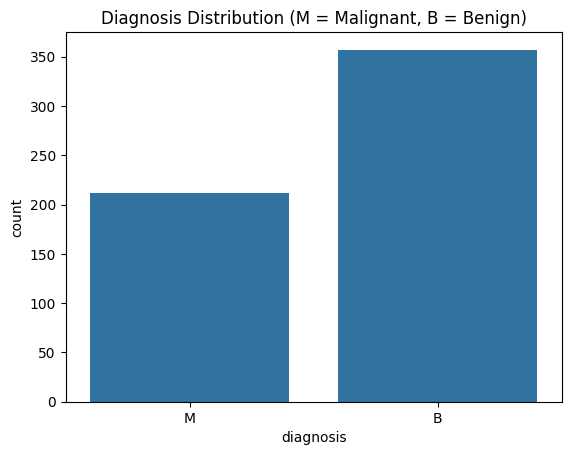

In [5]:
# ==============================
# 4. Target Distribution
# ==============================
print("\n🔹 Target Distribution:")
print(df["diagnosis"].value_counts())

sns.countplot(x="diagnosis", data=df)
plt.title("Diagnosis Distribution (M = Malignant, B = Benign)")
plt.show()


In [6]:
# ==============================
# 5. Data Cleaning
# ==============================
# Drop ID column (not useful for prediction)
df.drop("id", axis=1, inplace=True)

# Encode target variable
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

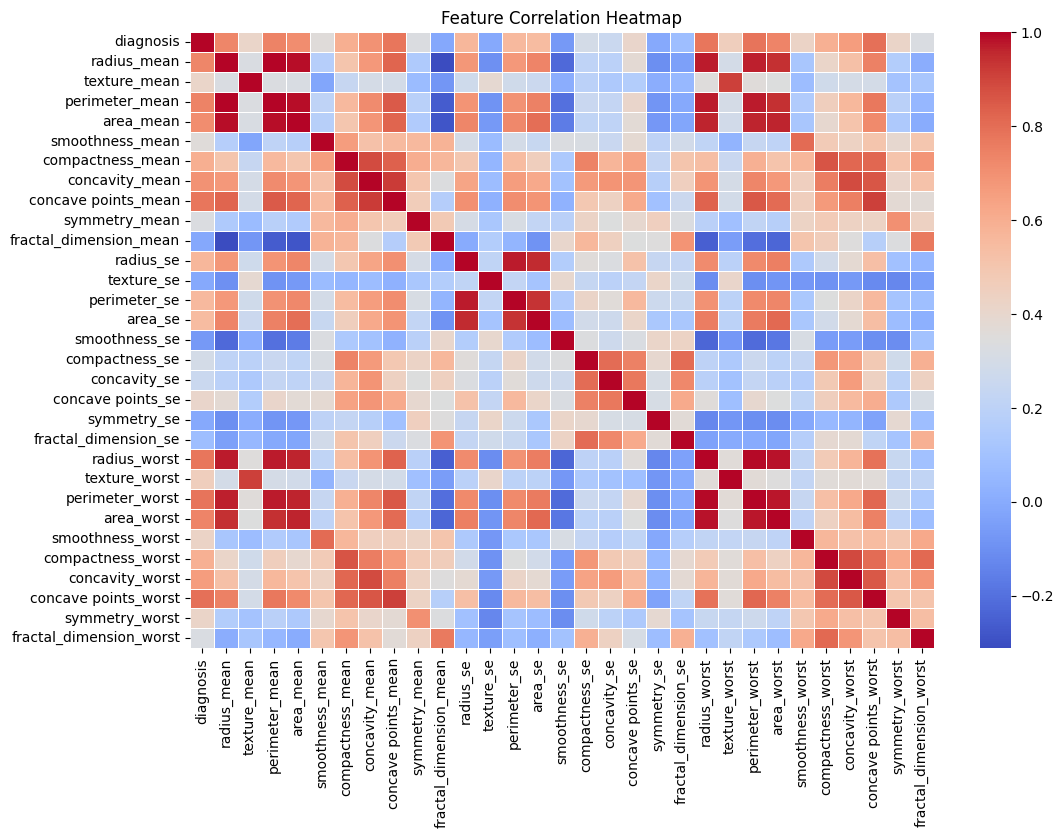

In [7]:
# ==============================
# 6. Correlation Analysis
# ==============================
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [8]:
# ==============================
# 7. Feature / Target Split
# ==============================
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

print("\n🔹 Features shape:", X.shape)
print("🔹 Target shape:", y.shape)


🔹 Features shape: (569, 30)
🔹 Target shape: (569,)


In [9]:
# ==============================
# 8. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n🔹 Train size:", X_train.shape)
print("🔹 Test size:", X_test.shape)


🔹 Train size: (455, 30)
🔹 Test size: (114, 30)


In [10]:
# ==============================
# 9. Feature Scaling
# ==============================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
# ==============================
# 10. Train SVM Model
# ==============================
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True
)

svm_model.fit(X_train_scaled, y_train)


SVC(C=10, probability=True)

In [12]:
# ==============================
# 11. Model Evaluation
# ==============================
y_pred = svm_model.predict(X_test_scaled)

print("\n==============================")
print("📊 MODEL PERFORMANCE")
print("==============================")

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



📊 MODEL PERFORMANCE

Accuracy: 0.9736842105263158

Confusion Matrix:
 [[72  0]
 [ 3 39]]

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [13]:
# ==============================
# 12. Hyperparameter Tuning
# ==============================
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.001, 0.0001],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("\n🔹 Best Parameters:", grid.best_params_)


🔹 Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}



AUC Score: 0.9927248677248677


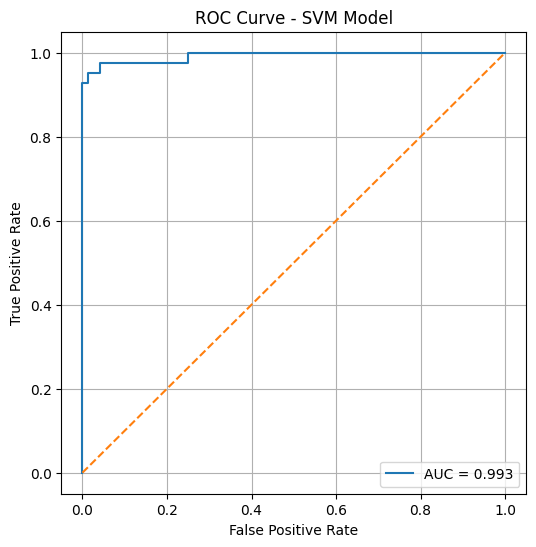

In [14]:
# ==============================
# 13. ROC Curve & AUC
# ==============================
y_probs = svm_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

print("\nAUC Score:", auc_score)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM Model")
plt.legend()
plt.grid()
plt.show()

In [15]:
import joblib

# ==============================
# Save trained model
# ==============================
joblib.dump(svm_model, "svm_breast_cancer_model.pkl")

# ==============================
# Save scaler (VERY IMPORTANT)
# ==============================
joblib.dump(scaler, "scaler.pkl")

print("Model and Scaler saved successfully ✅")

Model and Scaler saved successfully ✅


In [16]:
import joblib

# Load model
loaded_model = joblib.load("svm_breast_cancer_model.pkl")

# Load scaler
loaded_scaler = joblib.load("scaler.pkl")

print("Model loaded successfully ✅")

Model loaded successfully ✅


In [18]:
import numpy as np
import pandas as pd

# ==============================
# Take sample from test set
# ==============================
sample_size = 10

X_sample = X_test.iloc[:sample_size]
y_actual = y_test.iloc[:sample_size].values

# Scale data
X_sample_scaled = loaded_scaler.transform(X_sample)

# ==============================
# Predict probabilities + classes
# ==============================
y_probs = loaded_model.predict_proba(X_sample_scaled)[:, 1]
y_pred = loaded_model.predict(X_sample_scaled)

# ==============================
# Build results table
# ==============================
results = pd.DataFrame({
    "Actual": y_actual,
    "Predicted": y_pred,
    "Probability (Malignant)": y_probs
})

print(results)

   Actual  Predicted  Probability (Malignant)
0       0          0                 0.000153
1       1          1                 0.999998
2       0          0                 0.013417
3       1          0                 0.444238
4       0          0                 0.060282
5       0          0                 0.037751
6       1          1                 0.776664
7       0          0                 0.000955
8       0          0                 0.000288
9       0          0                 0.002084
